# CLN＋表面モードとFoster：DC条件と評価帯域を分けて実験する

確認したいのは、次の2点です。

1. 短いCLNに表面の補足モードを加えると、段数を増やしても残る誤差を減らせるか。
2. Fosterは遷移領域で同程度に正確で、DC誤差を許せば高周波側へ帯域を伸ばせるか。

**今回の結果では、高周波向けFosterは有効でした。ただし、改善の大部分は評価帯域の配分によるもので、DC条件を解除する追加効果は小さい結果でした。** また、非線形の丸棒では表面の補足基底で誤差の頭打ちを下げられました。この2つは別の実験で確認しています。

| 実験 | 基準 | 確認できること |
|---|---|---|
| 線形の円柱断面、一様横磁界 | Bessel解析解 | FEM誤差を除いたDC・帯域・打切りの比較 |
| 切欠き付きの3D導体、A–φ | 同じ有限要素行列の全モード応答 | 縮約方法の違い。メッシュを2種類使用 |
| 非線形の丸棒、FP-CLN＋表面基底 | 同じメッシュ・時間刻みの全自由度FP解 | 空間基底の補足による改善 |

いずれも実際に再計算した結果です。**独立したClaudeレビューは未実施**です。図表を再検査するセルは保存済みデータを読みます。FEM・最適化・時間積分を再実行する手順は末尾にあります。

## 比較の条件

Foster形とCauer形へ同じ縮約伝達関数を等価変換した場合、応答の精度は変わりません。ここで比較するのは、残す場の基底・極・評価帯域・静的条件の選び方です。[Otomo・Igarashiの論文](https://eprints.lib.hokudai.ac.jp/dspace/bitstream/2115/79884/2/Final_ver_TPEL_Cauer-1.pdf)もFosterからCauerへの変換を説明しています。

Fosterのモデルを

$$Z(u)=D+L_tu+\sum_{j=1}^{N}\frac{r_j u}{u+p_j},\quad p_j,r_j,D,L_t\geq0$$

と置きます。極は $-p_j$、各緩和項は並列RL枝のインピーダンスで、正の係数から受動な回路が得られます。

3Dの基準は正規化した磁気反応伝達関数 $Z(u)=u f^T(K+uM)^{-1}f$ です。静的傾きを1とする座標を使い、DC保持条件は $D=0$ と $L_t+\sum r_j/p_j=1$。これは静的応答の保持で、一般の電線のDC抵抗そのものを比較する実験ではありません。

以下の因子を別々に変えます。

- **低周波寄りの帯域**：0.1 Hz〜30 kHz。
- **高周波寄りの帯域**：1 kHz〜1 MHz。
- **DC保持**：DC値と静的傾きを固定。
- **DC自由**：この2条件を解除し、正の回路係数を帯域内で調整。

フィッティングは90点、評価は別の密なグリッドです。Fosterは4極、3Dの単一展開点CLNは4磁場基底から得るType1・8要素・R終端です。複数展開点CLNにも計4基底を使います。Fosterの静的抵抗・インダクタンス項は別に記録し、総素子数や自由パラメータ数まで完全に同じ比較とは扱いません。

帯域フィットのFosterは元の固有極をそのまま4つ残す方法とは異なります。初期値にはエネルギーGalerkinモデルを使い、極と留数を最適化します。元の固有ベクトルを保持するFosterなら場を復元できますが、この端子応答フィットだけからは場の復元を保証しません。

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
root=Path.cwd()
if not (root/'validation').is_dir():
    root=root.parent
load=lambda name:json.loads((root/'docs/data'/name).read_text(encoding='utf-8'))
circle=load('foster_circle_controlled.json')
three=load('foster_3d_fine.json')
coarse=load('foster_3d_coarse.json')
fp=load('fp_surface_fine.json')
print('3D:',three['mesh'])
print('max error [%]: transition / 1kHz--1MHz')
for key in ['CLN single point rank 4','CLN multipoint band rank 4',
            'Foster fitted DC rank 4','Foster fitted high+DC rank 4','Foster fitted band rank 4']:
    item=three['runs'][key]
    print(f"{key:34s} {100*item['transition_max']:.6f} / {100*item['high_band_max']:.6f}")
print('DC-preserved high-band fit versus DC-free high-band fit is the controlled comparison.')
for dataset in [circle,three,coarse]:
    for key,item in dataset['runs'].items():
        assert np.all(np.isfinite(item['relative_error']))
        if key.startswith('Foster fitted'):
            assert item['optimizer_converged']
            assert all(p>0 for p in item['poles'])
            assert all(r>0 for r in item['residues'])
print('Fit status and coefficient checks passed')


3D: {'maxh': 0.003, 'ne': 1640, 'free_A': 3142, 'physical_dimension': 1399, 'gradient_dimension': 1743, 'kernel_load_fraction': 2.20733003815541e-14, 'static_H': 7.475644956885984e-05, 'reference_build_seconds': 5.161357400007546}
max error [%]: transition / 1kHz--1MHz
CLN single point rank 4            0.002444 / 1.065738
CLN multipoint band rank 4         0.024468 / 0.073595
Foster fitted DC rank 4            0.000212 / 1.429206
Foster fitted high+DC rank 4       0.015995 / 0.033601
Foster fitted band rank 4          0.038524 / 0.032514
DC-preserved high-band fit versus DC-free high-band fit is the controlled comparison.
Fit status and coefficient checks passed


## 遷移領域と高周波域

円柱では $u=s\mu\sigma a^2$、$\delta/a=\sqrt{2/|u|}$。ここでは **$0.3\leq\delta/a\leq3$** を遷移領域と定義し、灰色で示します。この範囲は寸法と材料から計算したものです。

3Dも同じ材料と代表寸法 $a=10$ mmで周波数を区分します。切欠きがあるので、これをあらゆる局所寸法の遷移を代表する定義とは扱いません。

同じ高周波帯域でDC保持／自由を比較すると、今回DC条件を解除した効果は小さい結果でした。DCを保持したモデルでも高周波向けに調整できます。一方、低い固有極を順番に切り捨てるFosterが、常に広帯域で高精度になるわけではありません。

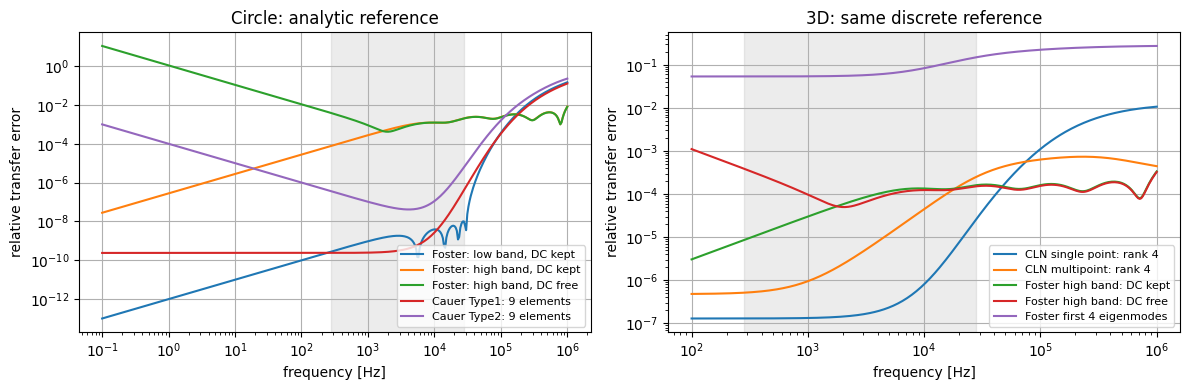

Circle controlled high-band comparison:
Foster fitted high+DC max error 0.00820860615054004 DC slope error 1.1102230246251565e-16 DC offset 0.0
Foster fitted band max error 0.008091025219132292 DC slope error 0.0008882085020776032 DC offset 0.0008667209323530656


In [2]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
labels={'Foster fitted DC':'Foster: low band, DC kept',
        'Foster fitted high+DC':'Foster: high band, DC kept',
        'Foster fitted band':'Foster: high band, DC free',
        'analytic CLN Type1 9 elements':'Cauer Type1: 9 elements',
        'analytic CLN Type2 9 elements':'Cauer Type2: 9 elements'}
for key,label in labels.items():
    axes[0].loglog(circle['frequency_hz'],np.maximum(circle['runs'][key]['relative_error'],1e-14),label=label)
labels3={'CLN single point rank 4':'CLN single point: rank 4',
         'CLN multipoint band rank 4':'CLN multipoint: rank 4',
         'Foster fitted high+DC rank 4':'Foster high band: DC kept',
         'Foster fitted band rank 4':'Foster high band: DC free',
         'Foster slow modes rank 4':'Foster first 4 eigenmodes'}
for key,label in labels3.items():
    axes[1].loglog(three['frequency_hz'],np.maximum(three['runs'][key]['relative_error'],1e-14),label=label)
for ax,d,title in zip(axes,[circle,three],['Circle: analytic reference','3D: same discrete reference']):
    f1=2/(3**2*2*np.pi*d['tau']); f2=2/(.3**2*2*np.pi*d['tau'])
    ax.axvspan(f1,f2,color='gray',alpha=.15)
    ax.set(xlabel='frequency [Hz]',ylabel='relative transfer error',title=title)
    ax.grid(True); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('Circle controlled high-band comparison:')
for k in ['Foster fitted high+DC','Foster fitted band']:
    v=circle['runs'][k]
    print(k,'max error',v['high_band_max'],'DC slope error',v['DC_slope_error'],'DC offset',v['DC_offset'])


## 3Dで何を検証したか

20×20×15 mmの導体に、上半分の角を削る切欠きを設けました。定常電位も場も3方向へ変化します。Aの接線成分を表面で拘束し、φを端面で指定、残りの面を自然境界とします。外部空気・戻り導体を含む実機モデルではありません。

A–φのスカラー補正を消去し、導電率行列を $M_{AA}-D^TK_\phi^{-1}D$ とします。curl行列の勾配零空間を除いた後、同じ正のエネルギー行列 $(K,M)$ と同じ入力 $f$ から全モデルを生成します。

CLN基底はType1のエネルギー漸化式・ポート短絡の補正から作ります。**エネルギーから得た8要素の回路応答とGalerkin応答を照合**し、さらに独立に再直交化したKrylov基底との一致を検査します。検証用の基準解には対称固有値解と直接解を使い、製品側のICCGを黙って別ソルバーへ切り替える処理にはしていません。

同じ縮約モデルの固有値表示はFoster形です。したがって、その等価変換だけで精度差は出ません。差が出るのは、元の固有モードを選別したときや、別の帯域で回路をフィットしたときです。

**高周波側の数値は同じ離散モデルに対する縮約誤差です。** メッシュ間の基準応答の差は、縮約誤差より大きく残っています。ここで小さな縮約誤差が得られても、そのまま連続体・実機の高周波精度とは呼べません。

In [3]:
for d in [coarse,three]:
    assert d['direct_reference_relative_difference']<1e-8
    print('mesh',d['mesh']['maxh'],'direct/modal difference',d['direct_reference_relative_difference'])
    for n in [4,8,12]:
        info=d['runs'][f'CLN single point rank {n}']
        assert info['circuit_elements_count']==2*n
        assert info['circuit_vs_ritz']<1e-6
        assert info['independent_span_response_difference']<1e-6
    print('CLN depth / independent rank:',[(x['requested'],x['independent_rank']) for x in d['depth_probe']])
zcoarse=np.asarray(coarse['reference_real'])+1j*np.asarray(coarse['reference_imag'])
zfine=np.asarray(three['reference_real'])+1j*np.asarray(three['reference_imag'])
print('max normalized reference difference between meshes:',np.max(abs(zcoarse/zfine-1)))
print('static response difference between meshes:',abs(coarse['mesh']['static_H']/three['mesh']['static_H']-1))


mesh 0.004 direct/modal difference 8.895505018787639e-16
CLN depth / independent rank: [(16, 16), (24, 24), (32, 32)]
mesh 0.003 direct/modal difference 1.7774914542289494e-15
CLN depth / independent rank: [(16, 16), (24, 24), (32, 32)]
max normalized reference difference between meshes: 0.03456172544280078
static response difference between meshes: 0.07190901525650528


## 表面の補足基底は、どの誤差を減らしたか

こちらは別の **2D非線形実験** です。半径10 mm、$\sigma=2\times10^6$ S/m、初期比透磁率200、飽和の尺度1.5 T、50 Hzの横磁界を印加します。

FPの一定線形核から作るCLN基底と、表面Steklovモードを追加のポートとして導体内へ延長した基底を混ぜます。外部空気は有限要素のSchur補行列で表面へ縮約します。コードの `surface="exact"` は **その離散外部モデルの完全な表面行列** を意味し、連続体の厳密解という意味ではありません。

CLN基底だけでは、候補13〜17本（独立7〜9本）に増やしても誤差がほぼ頭打ちでした。高次の角度モードに対応する表面ポートを補足すると、鎖交磁束と導体内のジュール損失の誤差が下がりました。

出力λには縮約された静的な空気項も含まれるため、これを除いた棒の反応の誤差も記録します。損失は、導体内の離散電界から第2周期の $\sum\Delta t\,\dot A^TM\dot A$ を積分します。入力仕事の周期積分とは分け、入力仕事には台形則を使います。反復過渡を含む2周期の計算であり、周期定常解と時間刻み収束を確認した値ではありません。

基底候補をそのまま数えず、正の固定線形エネルギーで規格化してSVDで独立性を検査します。候補25本は19本、候補61本は55本の独立基底になりました。図では実際の独立本数を使います。

これは基底の不足を補う実験です。線形Fosterと非線形FP-CLNを直接競わせた結果ではありません。また、表面モードを加えれば、どの3D実装でも後段の構築失敗が自動的に解消する、という保証ではありません。

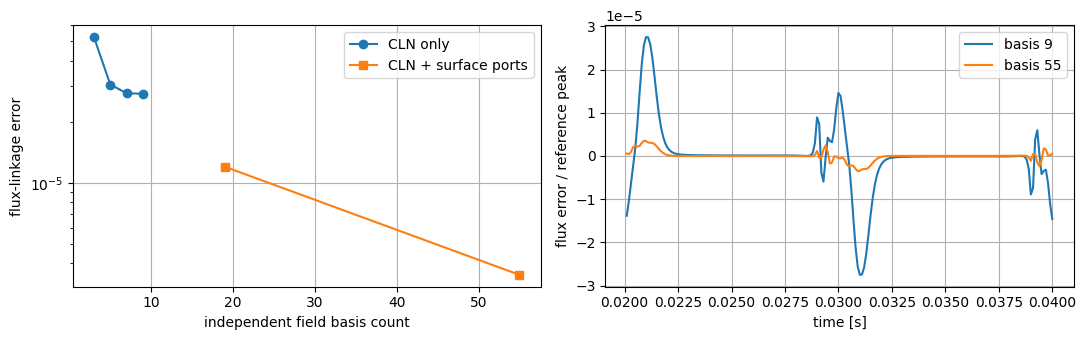

basis 9 flux error 2.751088847570405e-05 Joule-loss error 0.002258682397456434
basis 19 flux error 1.2003926697613118e-05 Joule-loss error 0.0017197851204848208
basis 55 flux error 3.515264822791728e-06 Joule-loss error 0.0006195900697831914
surface enrichment flux improvement factor: 7.826121177936075
Joule-loss improvement factor: 3.6454464130562934
reference cycle change: 0.0011802483264219744
rod-only linkage error: 5.3687199967118625e-05
same full-model / same backward-Euler step reference; no continuum or time-step convergence claim


In [4]:
keys=list(fp['runs'])
ranks=[fp['runs'][k]['basis'] for k in keys]
errors=[fp['runs'][k]['max_rel_err'] for k in keys]
loss_errors=[fp['runs'][k]['joule_relative_error'] for k in keys]
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
axes[0].semilogy(ranks[:4],errors[:4],'o-',label='CLN only')
axes[0].semilogy(ranks[4:],errors[4:],'s-',label='CLN + surface ports')
axes[0].set(xlabel='independent field basis count',ylabel='flux-linkage error')
axes[0].grid(True); axes[0].legend()
t=np.asarray(fp['time']); ref=np.asarray(fp['reference']['lambda_trace'])
mask=t>1/fp['f']; scale=np.max(abs(ref[mask]))
for k in [keys[3],keys[-1]]:
    row=fp['runs'][k]
    axes[1].plot(t[mask],(np.asarray(row['lambda_trace'])[mask]-ref[mask])/scale,label=f"basis {row['basis']}")
axes[1].set(xlabel='time [s]',ylabel='flux error / reference peak')
axes[1].grid(True); axes[1].legend()
plt.tight_layout(); plt.show()
for k in [keys[3],keys[4],keys[5]]:
    row=fp['runs'][k]
    print('basis',row['basis'],'flux error',row['max_rel_err'],'Joule-loss error',row['joule_relative_error'])
assert errors[-1]<.5*errors[3]
assert loss_errors[-1]<loss_errors[3]
print('surface enrichment flux improvement factor:',errors[3]/errors[-1])
print('Joule-loss improvement factor:',loss_errors[3]/loss_errors[-1])
print('reference cycle change:',fp['reference']['relative_cycle_change'])
print('rod-only linkage error:',fp['runs'][keys[-1]]['rod_linkage_relative_error'])
print('same full-model / same backward-Euler step reference; no continuum or time-step convergence claim')


## 再実行

計算コードは [validation/surface_hybrid](../validation/surface_hybrid/) にあります。numpy・scipy・mpmathを使用し、FEM計算にはNGSolveが必要です。リポジトリ直下から実行します。

```text
python validation/surface_hybrid/surface_modes_rod.py 3 0.2 surface.json
python validation/surface_hybrid/compare_circle.py --surface-results surface.json --output circle.json
python validation/surface_hybrid/compare_3d.py --maxh 0.004 --output three_coarse.json
python validation/surface_hybrid/compare_3d.py --maxh 0.003 --output three_fine.json
python validation/surface_hybrid/fp_cln_surface.py 2 0.2 fp_surface.json
python validation/surface_hybrid/validate_evidence.py
```

自己レビューは、共通の入力・出力・行列、静的条件、評価帯域、独立基底数、正のエネルギー、回路と場の縮約応答、Fosterへの等価変換、固定点反復の失敗検出を確認しています。構築時間も3Dデータに保存していますが、この小さな密行列ベンチの時間を大規模3Dのコスト見積りへ外挿しません。

**今回の結論**：帯域に合わせたFosterは有力です。DCを保持しても高周波側へ精度を配分でき、DC条件の解除の追加効果は今回小さい結果でした。複数展開点CLNも高周波誤差を下げました。非線形の表面補足基底は別途有効でした。単なるFoster/Cauerの表現の違いで優劣を決める結果ではありません。


## 同じ実励振で組み直した3D比較
[同じ実励振によるCLN・境界応答・POD](08_3d_surface_pod_foster.ipynb)では、CLNもPODも同じ実励振を使うことを確認し、単一/複数展開点CLN、CLN2＋実励振の境界応答補足を比較します。旧仮想境界ポートを本来の表面モードの代用にした結論は撤回し、境界応答のPODとSteklovモードを区別しました。